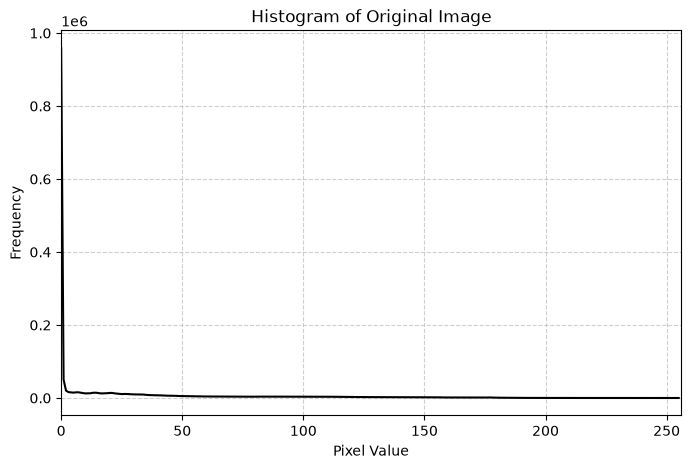

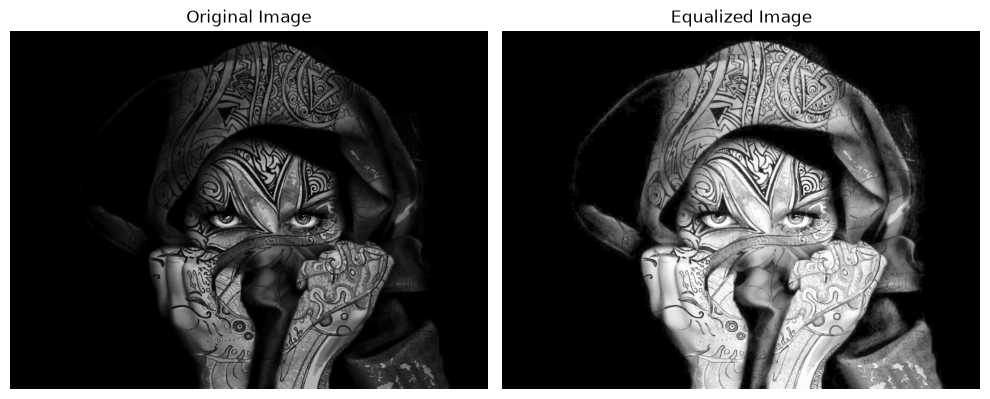

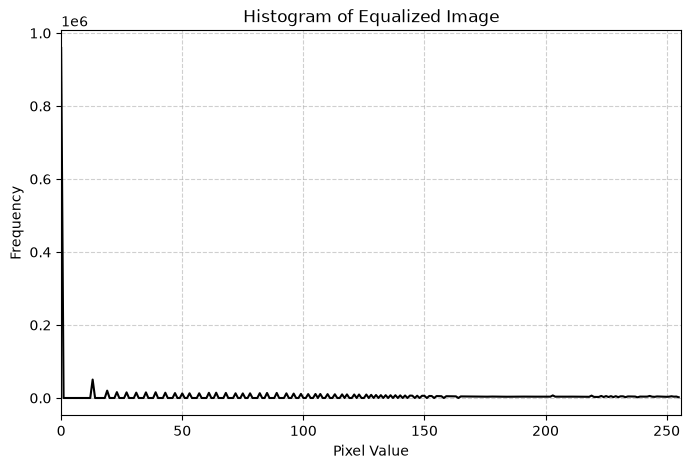

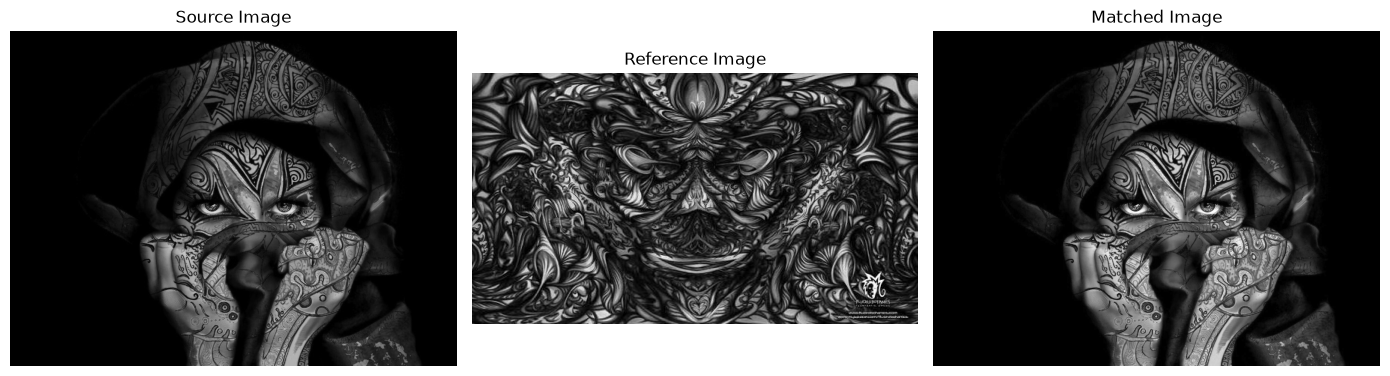

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys

image_path = r"C:\Users\Dev Radia\Desktop\image2.jpg"
source_path = r"C:\Users\Dev Radia\Desktop\image2.jpg"
reference_path = r"C:\Users\Dev Radia\Desktop\image3.jpg"

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    print(f"Error: Could not load image from {image_path}")
    sys.exit()

histogram = cv2.calcHist([image], [0], None, [256], [0, 256])

plt.figure(figsize=(8, 5))
plt.title('Histogram of Original Image')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.plot(histogram, color='black')
plt.xlim([0, 256])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

equalized_image = cv2.equalizeHist(image)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Equalized Image')
plt.imshow(equalized_image, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

equalized_hist = cv2.calcHist([equalized_image], [0], None, [256], [0, 256])

plt.figure(figsize=(8, 5))
plt.title('Histogram of Equalized Image')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.plot(equalized_hist, color='black')
plt.xlim([0, 256])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

source_image = cv2.imread(source_path, cv2.IMREAD_GRAYSCALE)
reference_image = cv2.imread(reference_path, cv2.IMREAD_GRAYSCALE)

if source_image is None:
    print(f"Error: Could not load source image from {source_path}")
    sys.exit()

if reference_image is None:
    print(f"Error: Could not load reference image from {reference_path}")
    sys.exit()

source_hist = cv2.calcHist([source_image], [0], None, [256], [0, 256])
reference_hist = cv2.calcHist([reference_image], [0], None, [256], [0, 256])

if source_hist.sum() > 0:
    source_hist /= source_hist.sum()

if reference_hist.sum() > 0:
    reference_hist /= reference_hist.sum()

source_cdf = source_hist.cumsum()
reference_cdf = reference_hist.cumsum()

if not np.any(np.isnan(source_cdf)) and not np.any(np.isnan(reference_cdf)) and len(source_cdf) > 0 and len(reference_cdf) > 0:
    mapping = np.interp(source_cdf, reference_cdf, range(256))
    matched_image = mapping[source_image]
    matched_image = matched_image.astype(np.uint8)
else:
    print("Warning: CDFs contain NaN values or are empty. Skipping matching.")
    matched_image = np.zeros_like(source_image, dtype=np.uint8)

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.title('Source Image')
plt.imshow(source_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Reference Image')
plt.imshow(reference_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Matched Image')
plt.imshow(matched_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()